# EL-GHALI MOHAMED

# Régression Linéaire Simple
Implémentation d'une régression linéaire à une seule variable (surface -> prix).


In [1]:
# Importation des librairies nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Définition du Modèle
La fonction calcule la droite d'équation `y = aX + b` à l'aide de la descente de gradient.


In [2]:
# Implémentation de la régression linéaire avec la descente de gradient
def simple_lineare_regression(X, Y, iterations, learning_rate):
    # Initialisation des paramètres de la droite
    a = 0.0
    b = 0.0
    m = len(Y) # Nombre total d'observations

    for i in range(iterations):
        # Calcul de la prédiction avec les paramètres actuels
        predire = a * X + b
        erreur = predire - Y

        # Calcul des dérivées partielles (gradients)
        d_a = np.sum(erreur * X) / m
        d_b = np.sum(erreur) / m

        # Mise à jour des poids a et b
        a -= learning_rate * d_a
        b -= learning_rate * d_b

        # Calcul de la fonction de coût (MSE) pour s'assurer que le modèle apprend
        mse = (np.sum(erreur**2)) / (2*m)

        # On affiche la perte toutes les 1000 itérations
        if i % 1000 == 0:
            print(f"Itération {i} | Loss (MSE): {mse:.2f}")

    return a, b

## 2. Création du Dataset
Création d'un jeu de 10 données  liant la surface d'une maison (`area` en m²) à son prix (`price`).

In [5]:
# Dictionnaire contenant nos données fictives
data_dict = {
    "area": [50, 60, 80, 100, 120, 150, 180, 200, 250, 300],
    "price": [150000, 180000, 220000, 280000, 320000, 400000, 480000, 550000, 680000, 800000]
}
# Conversion en DataFrame Pandas pour faciliter la manipulation
data = pd.DataFrame(data_dict)
data.head()

,area,price
0,50,150000
1,60,180000
2,80,220000
3,100,280000
4,120,320000


## 3. Entraînement et Visualisation
Nous utilisons directement les données brutes. Le `taux d'apprentissage` est réglé sur `1e-7`  et nous laissons tourner sur 1500 itérations pour obtenir une belle droite de régression.

Itération 0 | Loss (MSE): 103970000000.00
Itération 1000 | Loss (MSE): 397818382.23

Paramètres trouvés : a = 2665.9806, b = 14.4412


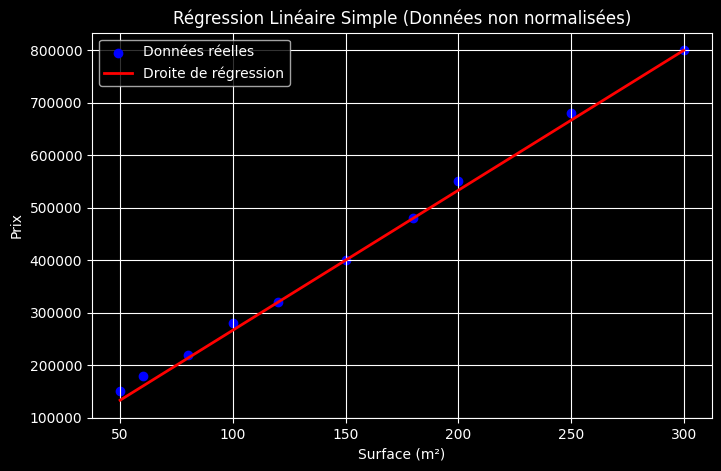

In [4]:
# Sélection des variables brutes
X = data["area"].values
Y = data["price"].values

# Lancement de l'entraînement
a, b = simple_lineare_regression(X, Y, iterations=1500, learning_rate=1e-7)

print(f"\nParamètres trouvés : a = {a:.4f}, b = {b:.4f}")

# Visualisation des données réelles et de la droite de régression trouvée par le modèle
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', label='Données réelles')

# Calcul des prédictions finales pour tracer la droite
Y_pred = a * X + b
plt.plot(X, Y_pred, color='red', linewidth=2, label='Droite de régression')

plt.xlabel("Surface (m²)")
plt.ylabel("Prix")
plt.title("Régression Linéaire Simple (Données non normalisées)")
plt.legend()
plt.grid(True)
plt.show()